In [1]:
import pandas as pd
import matplotlib.pyplot as plt

main_df = pd.read_csv(
    "../outputs/makueni_cropland_ndvi_rainfall_2020_2024.csv"
)

main_df["month"] = pd.to_datetime(
    main_df["month"]
)

In [2]:
rain_mean = main_df["rainfall_mm"].mean()

main_df["rainfall_anomaly"] = (
    main_df["rainfall_mm"] - rain_mean
)

main_df[["month", "rainfall_mm", "rainfall_anomaly"]].head()

,month,rainfall_mm,rainfall_anomaly
0,2020-01-01,118.317911,52.284798
1,2020-02-01,56.757018,-9.276095
2,2020-03-01,171.246656,105.213543
3,2020-04-01,202.196964,136.163851
4,2020-05-01,22.359689,-43.673424


In [3]:
rain_std = main_df["rainfall_mm"].std()

main_df["rainfall_z"] = (
    main_df["rainfall_mm"] - rain_mean
) / rain_std

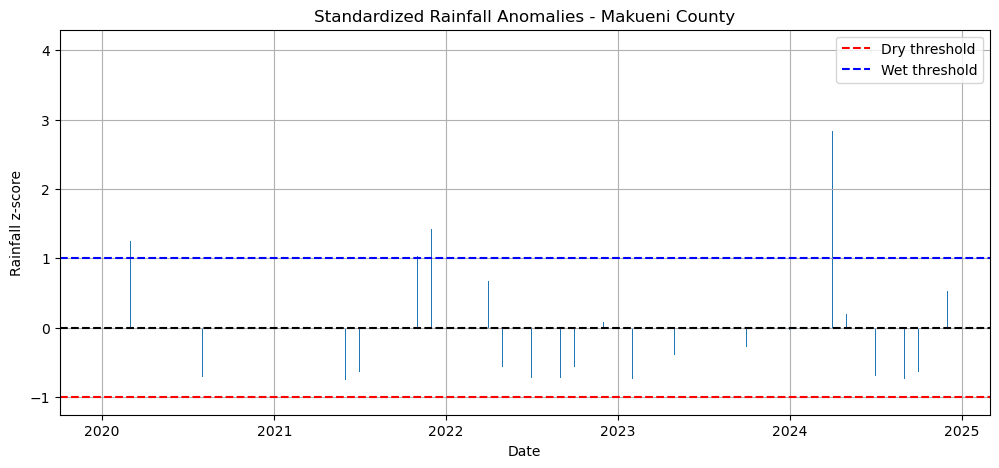

In [4]:
fig, ax = plt.subplots(figsize=(12,5))

ax.bar(
    main_df["month"],
    main_df["rainfall_z"]
)

ax.axhline(0, color="black", linestyle="--")
ax.axhline(-1, color="red", linestyle="--", label="Dry threshold")
ax.axhline(1, color="blue", linestyle="--", label="Wet threshold")

ax.set_title("Standardized Rainfall Anomalies - Makueni County")
ax.set_ylabel("Rainfall z-score")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True)

fig.savefig(
    "../docs/images/makueni_rainfall_anomalies_2020_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
dry_months = main_df[
    main_df["rainfall_z"] < -1
]

dry_months[
    ["month", "rainfall_mm", "rainfall_anomaly", "rainfall_z", "mean_ndvi_cropland"]
]

,month,rainfall_mm,rainfall_anomaly,rainfall_z,mean_ndvi_cropland


In [6]:
wet_months = main_df[
    main_df["rainfall_z"] > 1
]

wet_months[
    ["month", "rainfall_mm", "rainfall_anomaly", "rainfall_z", "mean_ndvi_cropland"]
]

,month,rainfall_mm,rainfall_anomaly,rainfall_z,mean_ndvi_cropland
2,2020-03-01,171.246656,105.213543,1.251611,0.611866
3,2020-04-01,202.196964,136.163851,1.619794,0.518249
10,2020-11-01,206.395682,140.362568,1.669741,0.290745
22,2021-11-01,152.697074,86.663961,1.030947,0.177018
23,2021-12-01,186.233401,120.200288,1.429893,0.483551
39,2023-04-01,165.047111,99.013998,1.177862,0.322423
46,2023-11-01,405.738460,339.705347,4.041106,0.435566
51,2024-04-01,304.464194,238.431081,2.836356,0.406953
58,2024-11-01,262.100963,196.067850,2.332407,0.214911


In [7]:
main_df.to_csv(
    "../outputs/makueni_cropland_ndvi_rainfall_anomalies_2020_2024.csv",
    index=False
)

In [8]:
main_df["rainfall_mm"].describe()

count     60.000000
mean      66.033113
std       84.062463
min        2.491424
25%        7.057140
50%       24.735108
75%      102.707769
max      405.738460
Name: rainfall_mm, dtype: float64

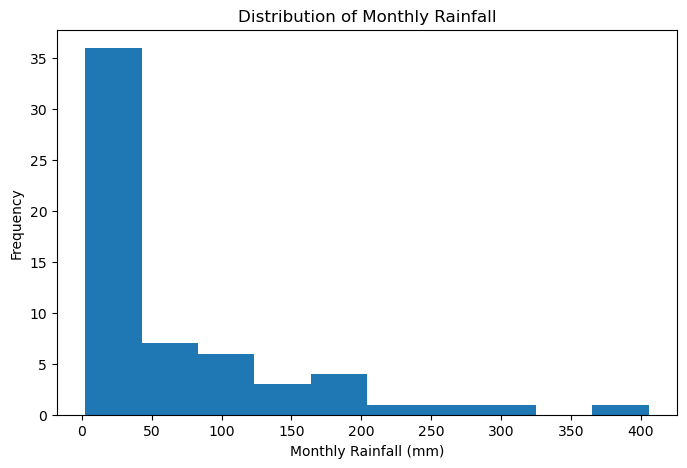

In [9]:
plt.figure(figsize=(8,5))

plt.hist(main_df["rainfall_mm"], bins=10)

plt.xlabel("Monthly Rainfall (mm)")
plt.ylabel("Frequency")
plt.title("Distribution of Monthly Rainfall")

plt.show()

In [10]:
threshold = main_df["rainfall_mm"].quantile(0.25)

print(threshold)

7.057140328680212


In [11]:
dry_months = main_df[
    main_df["rainfall_mm"] <= threshold
]

dry_months

,month,mean_ndvi_cropland,rainfall_mm,rainfall_lag1,rainfall_lag2,rainfall_anomaly,rainfall_z
7,2020-08-01,0.274766,6.516741,11.160580,8.792400,-59.516373,-0.708002
8,2020-09-01,0.197690,6.753315,6.516741,11.160580,-59.279799,-0.705188
17,2021-06-01,0.424096,2.491424,81.075427,100.049887,-63.541690,-0.755887
20,2021-09-01,0.157697,3.359036,7.092879,11.939216,-62.674077,-0.745566
29,2022-06-01,0.185995,4.881197,18.761567,123.204550,-61.151916,-0.727458
30,2022-07-01,0.235112,5.219007,4.881197,18.761567,-60.814107,-0.723440
31,2022-08-01,0.161119,5.185345,5.219007,4.881197,-60.847769,-0.723840
32,2022-09-01,0.171337,5.166611,5.185345,5.219007,-60.866503,-0.724063
37,2023-02-01,0.260122,3.766772,14.535096,72.561678,-62.266341,-0.740715
42,2023-07-01,0.256834,6.383287,7.374644,33.181699,-59.649826,-0.709589


In [12]:
main_df.to_csv(
    "../outputs/makueni_cropland_ndvi_rainfall_anomalies_2020_2024.csv",
    index=False
)